In [1]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import the XGBoost classifier
from xgboost import XGBClassifier

# Import evaluation metrics to measure model performance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load the training feature dataset
X_train = pd.read_csv("../Dataset/X_train.csv")

# Load the testing feature dataset
X_test = pd.read_csv("../Dataset/X_test.csv")

# Load the training target variable
y_train = pd.read_csv("../Dataset/y_train.csv").squeeze()

# Load the testing target variable
y_test = pd.read_csv("../Dataset/y_test.csv").squeeze()

In [3]:
# Display the shape of the training and testing datasets
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

# Display the shape of the target variables
print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (8259, 157)
Testing Features Shape  : (2065, 157)
Training Labels Shape   : (8259,)
Testing Labels Shape    : (2065,)


In [4]:
# Remove unsupported characters from feature names
X_train.columns = (
    X_train.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

X_test.columns = (
    X_test.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

print("Feature names cleaned successfully!")

Feature names cleaned successfully!


In [5]:
# Initialize the XGBoost classifier with predefined parameters
# random_state ensures reproducible results
# eval_metric is used to evaluate the model during training
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train the XGBoost model using the training dataset
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [6]:
# Predict the target values using the trained model
y_pred = xgb_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [7]:
# Calculate important classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the evaluation results
print("=" * 40)
print("XGBoost Model Performance")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

XGBoost Model Performance
Accuracy : 0.8949
Precision: 0.5794
Recall   : 0.3080
F1 Score : 0.4022


In [8]:
# Display the detailed classification report
print("=" * 40)
print("Classification Report")
print("=" * 40)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1828
           1       0.58      0.31      0.40       237

    accuracy                           0.89      2065
   macro avg       0.75      0.64      0.67      2065
weighted avg       0.88      0.89      0.88      2065



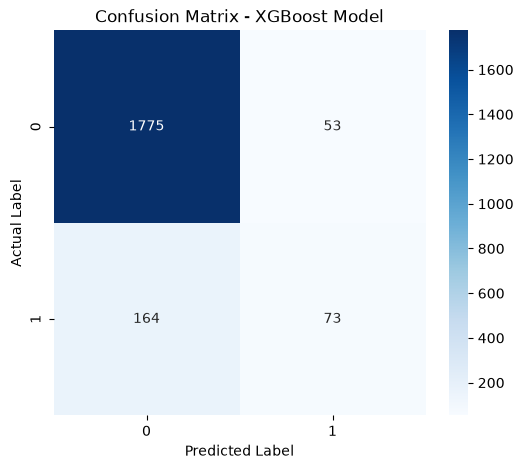

In [9]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Add labels and title
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGBoost Model")

# Display the plot
plt.show()

In [10]:
# Import joblib to save the trained machine learning model
import joblib

# Save the trained XGBoost model for future predictions
joblib.dump(xgb_model, "../Models/xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [11]:
# Extract feature importance scores from the trained model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 most important features
feature_importance.head(10)

,Feature,Importance
29,Fulfill Via_From RDC,0.094994
19,Country_South Africa,0.055049
16,Country_Nigeria,0.050061
32,Vendor INCO Term_DDP,0.044656
9,Scheduled Year,0.030041
84,Molecule/Test Type_Lamivudine,0.021088
23,Country_Vietnam,0.020191
50,Vendor_Aurobindo Pharma Limited,0.019684
98,Brand_Generic,0.018252
97,Brand_Determine,0.017781


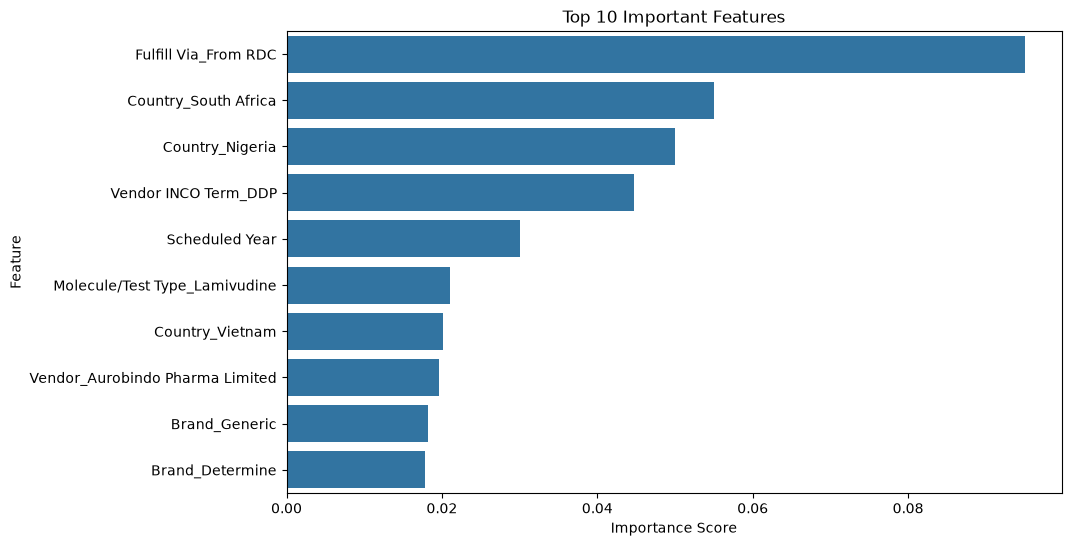

In [12]:
# Plot the top 10 most important features
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

In [13]:
print("Top 10 Important Features")
display(feature_importance.head(10))

Top 10 Important Features


,Feature,Importance
29,Fulfill Via_From RDC,0.094994
19,Country_South Africa,0.055049
16,Country_Nigeria,0.050061
32,Vendor INCO Term_DDP,0.044656
9,Scheduled Year,0.030041
84,Molecule/Test Type_Lamivudine,0.021088
23,Country_Vietnam,0.020191
50,Vendor_Aurobindo Pharma Limited,0.019684
98,Brand_Generic,0.018252
97,Brand_Determine,0.017781
